In [6]:
# ============================================
# Extract the already-uploaded zip file
# ============================================
import zipfile
import os

zip_path = '/content/breast+cancer+wisconsin+diagnostic.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/breast_cancer_data')

# Check what got extracted
print(os.listdir('/content/breast_cancer_data'))

['wdbc.data', 'wdbc.names']


In [7]:
import pandas as pd

base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['ID', 'Diagnosis'] + \
          [f'{f}_mean' for f in base_features] + \
          [f'{f}_se' for f in base_features] + \
          [f'{f}_worst' for f in base_features]

data_path = '/content/breast_cancer_data/wdbc.data'
df = pd.read_csv(data_path, header=None, names=columns)

print(df.shape)
df.head()

(569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
# ============================================
# TASK 1: Data Acquisition and Exploration
# ============================================

print("Shape:", df.shape)

Shape: (569, 32)


In [9]:
print(df.describe().T)

                         count          mean           std          min  \
ID                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave_points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.773127e-01     0.111500   
texture_se               

In [10]:
print("\nMissing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

feature_cols = [c for c in df.columns if c not in ['ID', 'Diagnosis']]
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[feature_cols] < (Q1 - 1.5*IQR)) | (df[feature_cols] > (Q3 + 1.5*IQR))).sum()
print("\nOutlier counts per feature (top 10):\n", outlier_counts.sort_values(ascending=False).head(10))

df = df.drop_duplicates().dropna()


Missing values:
 0
Duplicate rows: 0

Outlier counts per feature (top 10):
 area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
dtype: int64


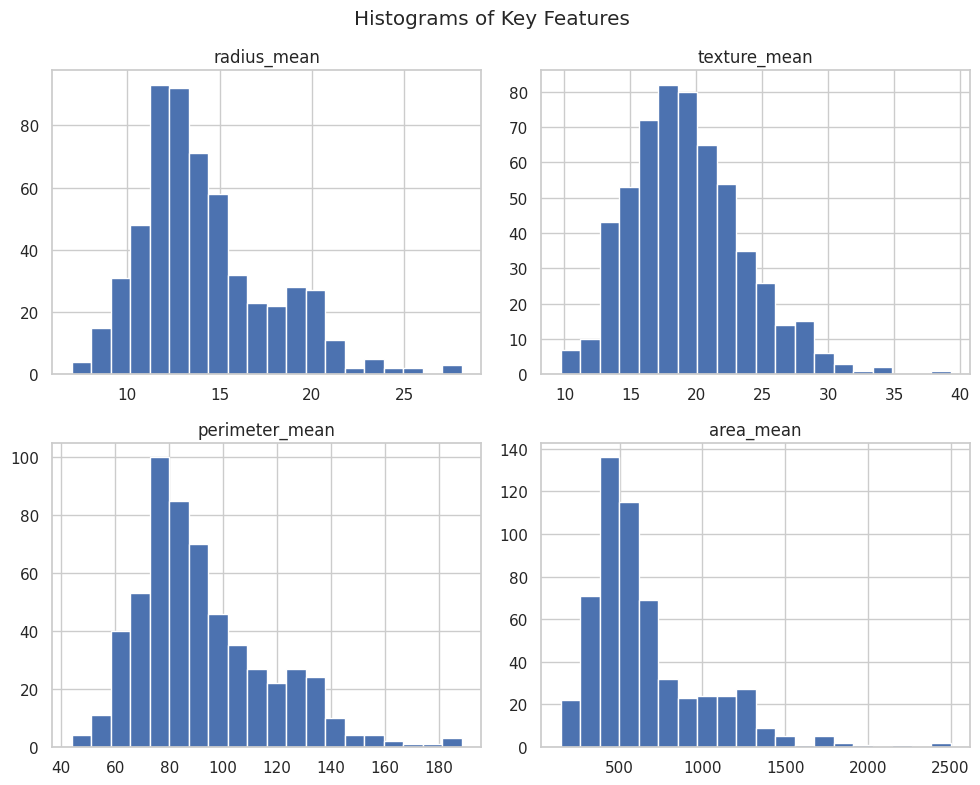

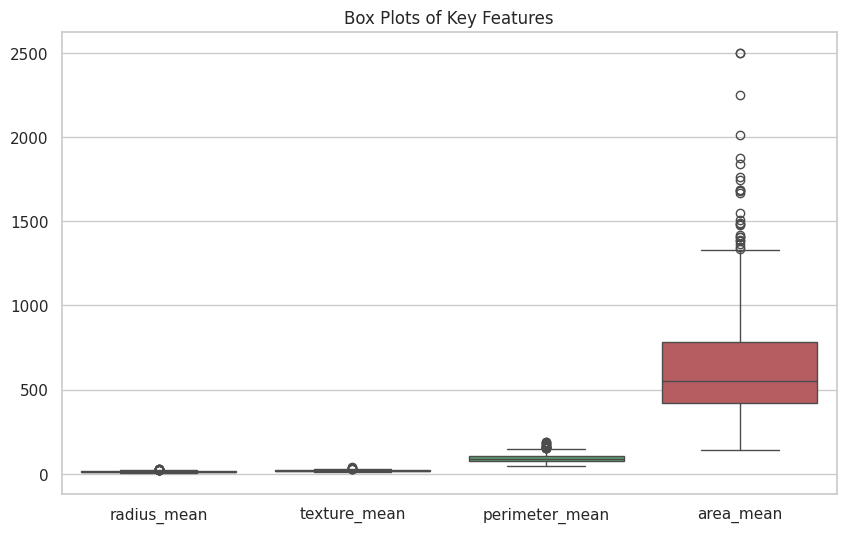

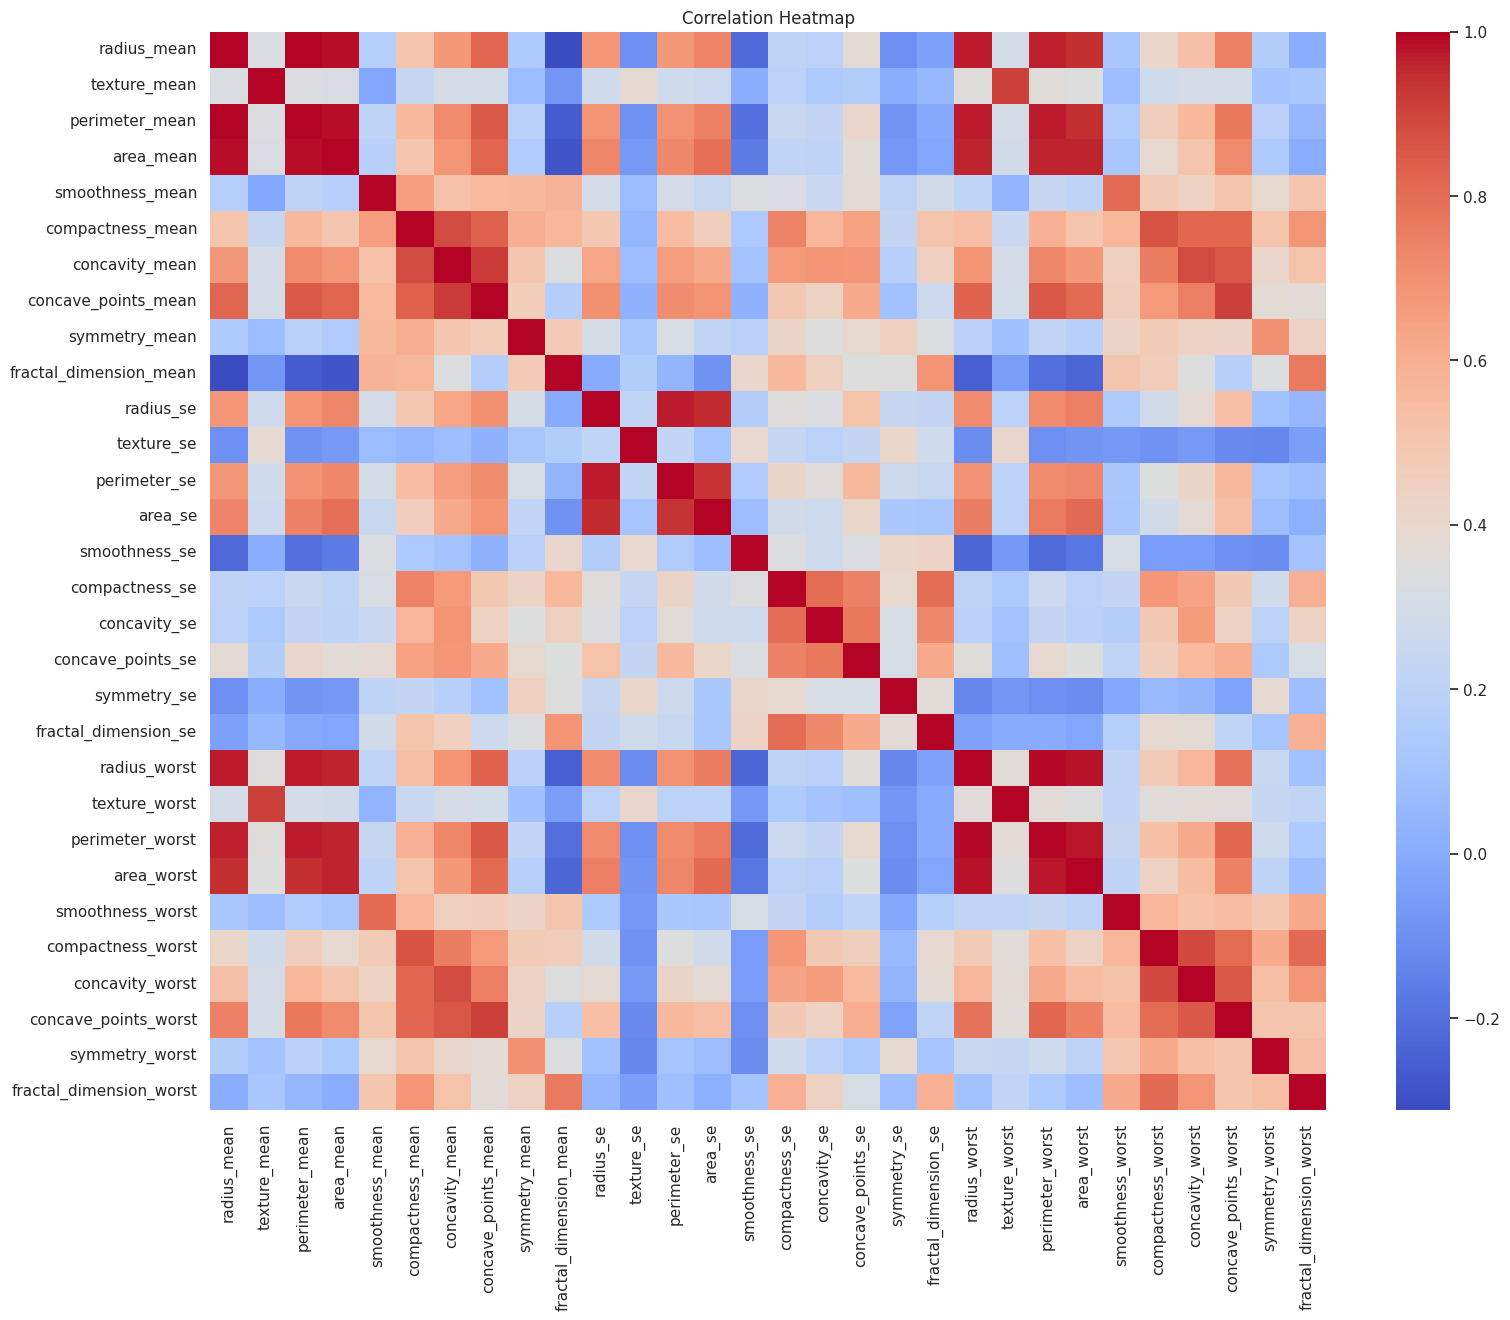

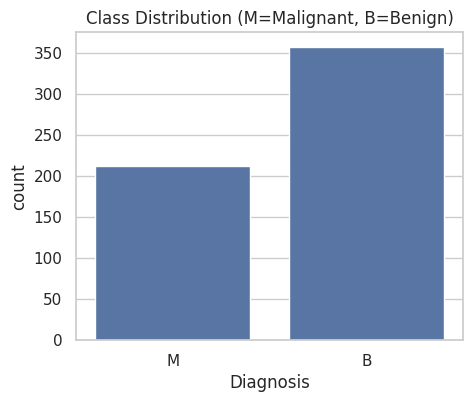

Diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [11]:
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

df[key_features].hist(bins=20, figsize=(10, 8))
plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[key_features])
plt.title("Box Plots of Key Features")
plt.show()

plt.figure(figsize=(18, 14))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x='Diagnosis', data=df)
plt.title("Class Distribution (M=Malignant, B=Benign)")
plt.show()
print(df['Diagnosis'].value_counts(normalize=True))

In [12]:
# ============================================
# TASK 2: Data Preprocessing
# ============================================

# Encode target: M -> 1, B -> 0
df['Outcome'] = df['Diagnosis'].map({'M': 1, 'B': 0})

X = df[feature_cols]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train class balance:
 Outcome
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Test class balance:
 Outcome
0    0.631579
1    0.368421
Name: proportion, dtype: float64


Accuracy: 0.9649

Classification Report:

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



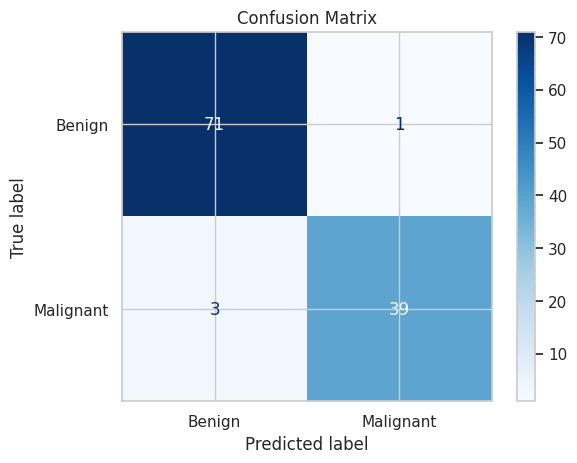

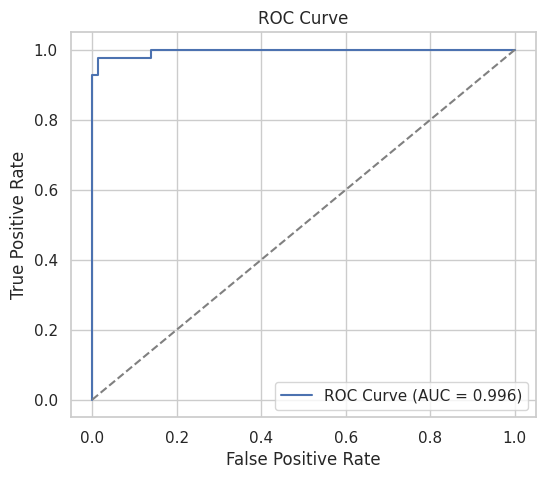

AUC Score: 0.9960


In [13]:
# ============================================
# TASK 3: Model Training and Evaluation
# ============================================

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")